# Jabłka vs pomidory — klasyfikacja klasyczna

Projekt na wizję komputerową. Bez sieci neuronowych — same klasyczne cechy
(tekstura, kolor, kształt) i klasyczne klasyfikatory (SVM, drzewo, las, kNN,
regresja logistyczna). Kolejność: wczytanie → preprocessing → cechy →
trening i dobór parametrów → ocena na osobnym zbiorze testowym → analiza.

Funkcje siedzą w pakiecie `cvproject`, tutaj tylko je składamy w całość.

In [1]:
import sys
sys.path.insert(0, "../src")

import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cvproject import config, data, preprocessing, features, classification, metrics, viz
from cvproject.config import RNG

%matplotlib inline
np.random.seed(RNG)

## 1. Wczytanie danych

Zbiór ma już gotowy podział na foldery `train` i `test`, więc `test` traktujemy
jako nasz odłożony zbiór testowy.

In [2]:
cfg = config.get_config()        # apples_tomatoes
X_train_img, y_train_str, X_test_img, y_test_str = data.load_presplit(cfg)

print("treningowe:", dict(collections.Counter(y_train_str)))
print("testowe:   ", dict(collections.Counter(y_test_str)))

treningowe: {'apple': 164, 'tomato': 130}
testowe:    {'apple': 54, 'tomato': 43}


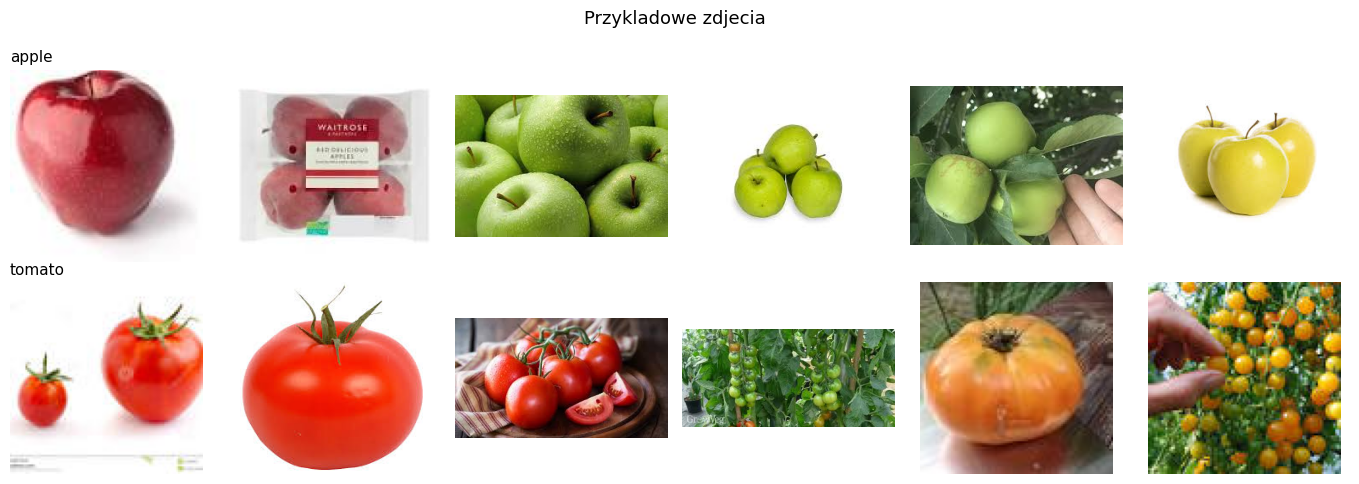

In [3]:
viz.show_class_samples(X_train_img, y_train_str, n_per_class=6,
                       suptitle="Przykladowe zdjecia")
plt.show()

## 2. Preprocessing

Po kolei: odszumianie filtrem medianowym, balans bieli (gray-world), CLAHE na
kanale L (Lab) i segmentacja owocu od tła w HSV. Otsu się sypał na zielonym /
kolorowym tle, więc segmentujemy po kolorze (owoce mają ciepłe barwy) — to
pokazujemy jeszcze raz liczbowo w sekcji 7.

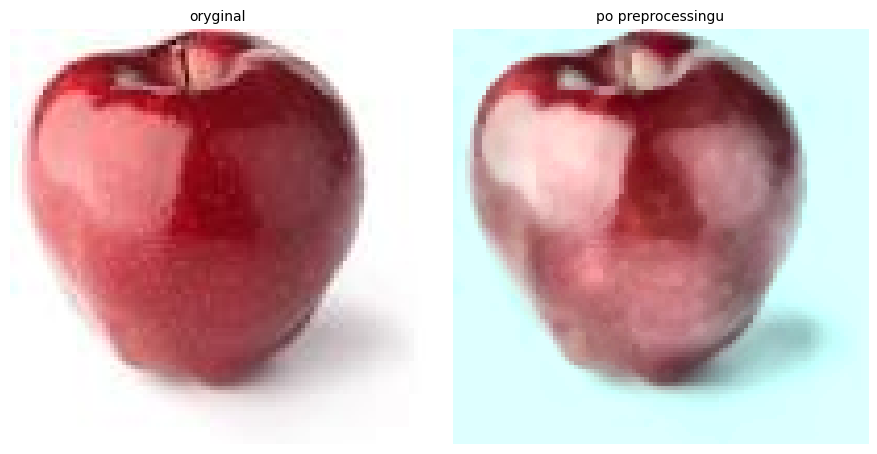

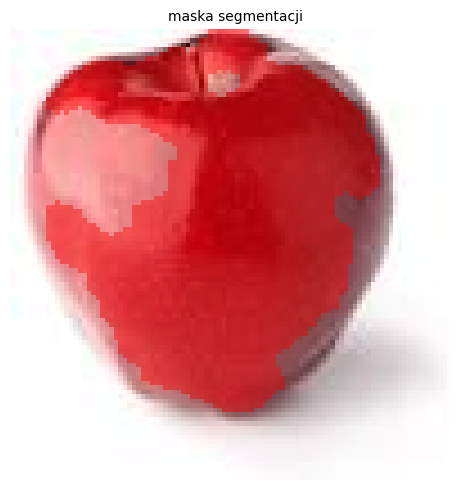

In [4]:
img0 = X_train_img[0]
proc0, mask0 = preprocessing.preprocess(img0)
viz.show_pair(img0, proc0, titles=("oryginal", "po preprocessingu"))
plt.show()
viz.show_mask_overlay(img0, mask0, title="maska segmentacji")
plt.show()

In [5]:
def przetworz(imgs):
    proc, masks = [], []
    for im in imgs:
        p, m = preprocessing.preprocess(im)
        proc.append(p)
        masks.append(m)
    return proc, masks

proc_train, masks_train = przetworz(X_train_img)
proc_test, masks_test = przetworz(X_test_img)

## 3. Ekstrakcja cech

Liczymy wszystko, co się da: tekstura (GLCM + LBP), kolor (statystyki dla
RGB/HSV/Lab + histogram odcienia) oraz kształt (geometria konturu, momenty Hu,
deskryptory Fouriera, momenty Zernike'a). Razem ponad 200 cech na obraz.

In [6]:
USE = features.DEFAULT_USE
X_tr, feat_names = features.build_feature_matrix(proc_train, masks_train, use=USE)
X_te, _ = features.build_feature_matrix(proc_test, masks_test, use=USE)
print("macierz cech:", X_tr.shape, "->", len(feat_names), "cech")
print("rodziny:", USE)

macierz cech: (294, 203) -> 203 cech
rodziny: ('glcm', 'color', 'huehist', 'lbp', 'shape', 'hu', 'fourier', 'geom', 'zernike')


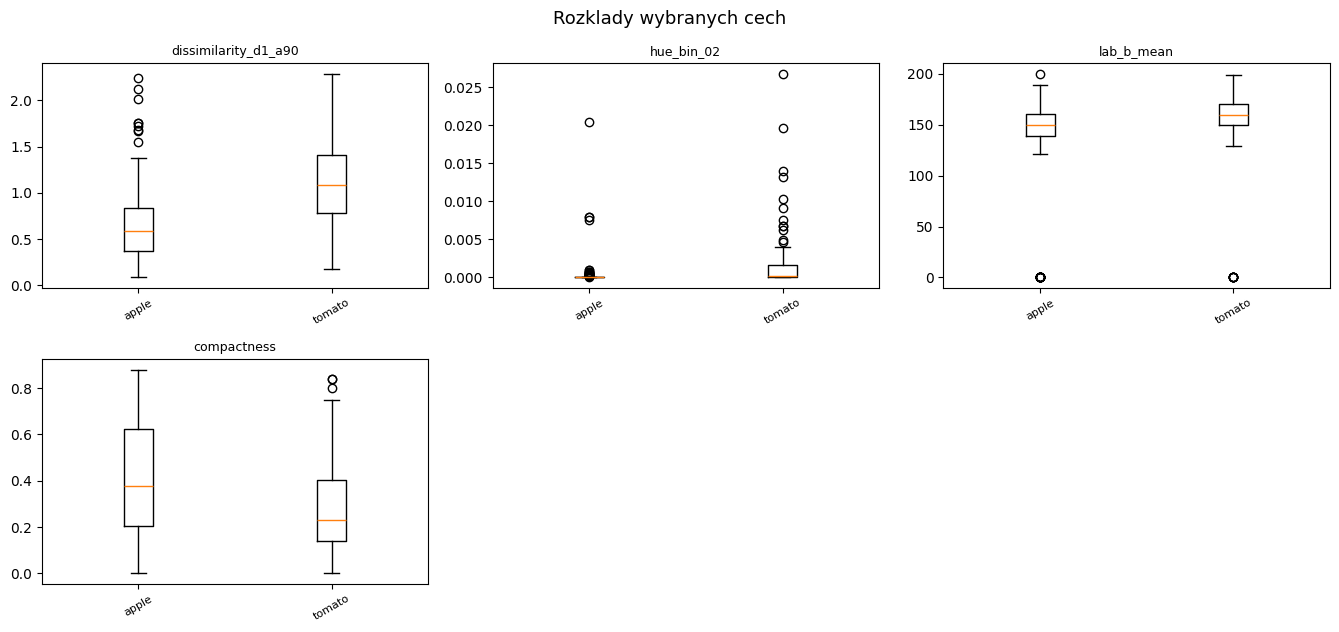

In [7]:
# rozklady kilku cech, ktore powinny rozdzielac klasy
wybrane = ["dissimilarity_d1_a90", "hue_bin_02", "lab_b_mean", "compactness"]
idx = [feat_names.index(n) for n in wybrane if n in feat_names]
viz.plot_feature_distributions(X_tr, y_train_str, feat_names, feature_idx=idx,
                               suptitle="Rozklady wybranych cech")
plt.show()

## 4. Podział train / walidacja / test

Test = gotowy zbiór testowy. Walidację (20%) wydzielamy z treningu i używamy jej
do wyboru najlepszego modelu. Hiperparametry stroimy walidacją krzyżową na
treningu.

In [8]:
y_train, le = data.encode_labels(y_train_str)
y_test = le.transform(y_test_str)
splits = data.make_splits(X_tr, y_train, val_size=0.2, presplit=(X_te, y_test))
for k, v in splits.items():
    print(k, np.asarray(v).shape)

X_train (235, 203)
y_train (235,)
X_val (59, 203)
y_val (59,)
X_test (97, 203)
y_test (97,)


## 5. Trening i dobór parametrów

Każdy model to `StandardScaler` + klasyfikator. Parametry dobieramy przez
`GridSearchCV` (walidacja krzyżowa, metryka f1_macro) na zbiorze treningowym.

In [9]:
models = classification.build_models()
tuned = {}
for name, model in models.items():
    grid = classification.PARAM_GRIDS.get(name, {})
    search = classification.tune(model, grid, splits["X_train"], splits["y_train"])
    tuned[name] = search.best_estimator_
    print(f"{name:14s} CV f1={search.best_score_:.3f}  {search.best_params_}")

svm            CV f1=0.790  {'clf__C': 100, 'clf__gamma': 0.001, 'clf__kernel': 'rbf'}


decision_tree  CV f1=0.751  {'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__min_samples_leaf': 1}


random_forest  CV f1=0.826  {'clf__max_depth': 10, 'clf__max_features': 'log2', 'clf__n_estimators': 100}


knn            CV f1=0.759  {'clf__n_neighbors': 7, 'clf__weights': 'distance'}
logreg         CV f1=0.787  {'clf__C': 0.1}


In [10]:
# najlepszy model wybieramy po zbiorze walidacyjnym (test zostaje nietkniety)
val_f1 = {name: metrics.evaluate(splits["y_val"], est.predict(splits["X_val"]))["f1_macro"]
          for name, est in tuned.items()}
best_name = max(val_f1, key=val_f1.get)
print("walidacja f1_macro:", {k: round(v, 3) for k, v in val_f1.items()})
print("najlepszy:", best_name)

walidacja f1_macro: {'svm': 0.761, 'decision_tree': 0.761, 'random_forest': 0.761, 'knn': 0.777, 'logreg': 0.757}
najlepszy: knn


## 6. Ocena na zbiorze testowym

In [11]:
preds = classification.predict_all(tuned, splits["X_test"])
tabela = metrics.compare_models(preds, splits["y_test"])
tabela.round(3)

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
knn,0.814,0.815,0.807,0.810,0.815,0.814,0.813
decision_tree,0.773,0.779,0.761,0.764,0.777,0.773,0.769
logreg,0.763,0.775,0.747,0.750,0.771,0.763,0.756
random_forest,0.753,0.751,0.745,0.747,0.752,0.753,0.751
svm,0.753,0.761,0.738,0.740,0.758,0.753,0.747


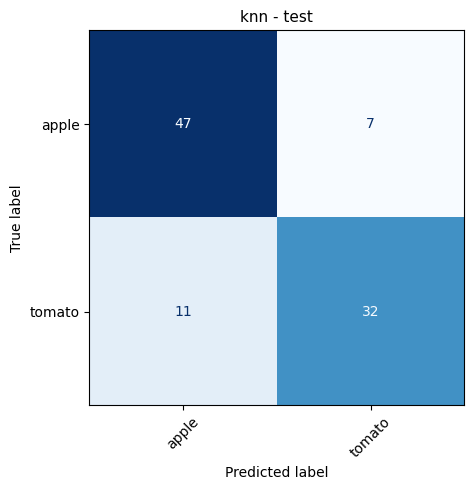

              precision    recall  f1-score   support

       apple       0.81      0.87      0.84        54
      tomato       0.82      0.74      0.78        43

    accuracy                           0.81        97
   macro avg       0.82      0.81      0.81        97
weighted avg       0.81      0.81      0.81        97



In [12]:
cm = metrics.confusion(splits["y_test"], preds[best_name])
viz.plot_confusion_matrix(cm, le.classes_, title=f"{best_name} - test")
plt.show()
print(metrics.report(splits["y_test"], preds[best_name], target_names=list(le.classes_)))

## 7. Analiza — co właściwie napędza klasyfikację?

Tu sprawdzamy, które cechy realnie działają (a nie tylko deklaratywnie).

### 7.1 PCA — jak bardzo klasy się nakładają

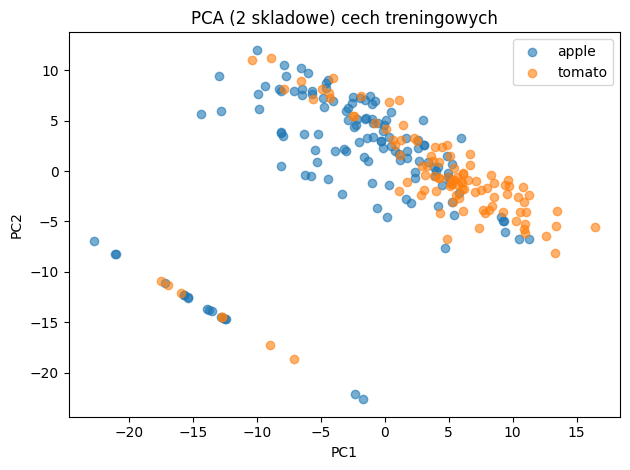

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Xs = StandardScaler().fit_transform(splits["X_train"])
pca = PCA(n_components=2, random_state=RNG).fit_transform(Xs)
for k in np.unique(splits["y_train"]):
    sel = splits["y_train"] == k
    plt.scatter(pca[sel, 0], pca[sel, 1], label=le.classes_[k], alpha=0.6)
plt.legend(); plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA (2 skladowe) cech treningowych"); plt.tight_layout(); plt.show()

### 7.2 Ważność cech (RandomForest)

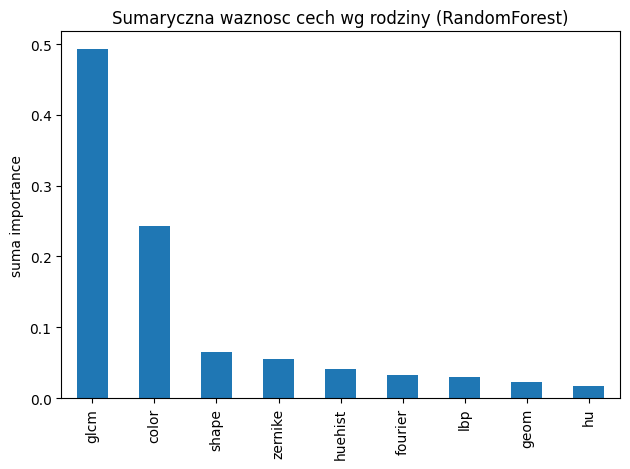

glcm       0.493
color      0.243
shape      0.065
zernike    0.055
huehist    0.042
fourier    0.032
lbp        0.029
geom       0.023
hu         0.017
dtype: float64

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=400, random_state=RNG).fit(splits["X_train"], splits["y_train"])
imp = rf.feature_importances_
rodzina = np.array([f for f in USE for _ in features.feature_names((f,))])
waznosc_rodzin = pd.Series(imp, index=rodzina).groupby(level=0).sum().sort_values(ascending=False)

waznosc_rodzin.plot.bar(title="Sumaryczna waznosc cech wg rodziny (RandomForest)")
plt.ylabel("suma importance"); plt.tight_layout(); plt.show()
waznosc_rodzin.round(3)

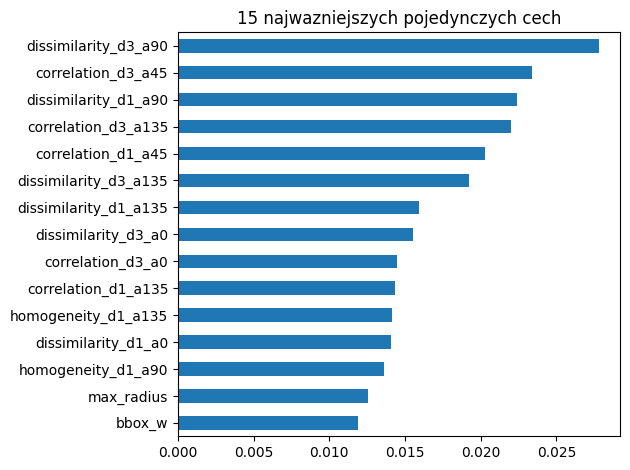

In [15]:
top = pd.Series(imp, index=feat_names).sort_values(ascending=False).head(15)
top.iloc[::-1].plot.barh(title="15 najwazniejszych pojedynczych cech")
plt.tight_layout(); plt.show()

### 7.3 Ablacja rodzin cech

Każda rodzina osobno (i kilka kombinacji), ten sam klasyfikator (SVM) i ta sama
walidacja krzyżowa na treningu. To uczciwy test, która rodzina sama z siebie
najlepiej rozdziela klasy.

In [16]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

offsets, start = {}, 0
for f in USE:
    n = len(features.feature_names((f,)))
    offsets[f] = list(range(start, start + n)); start += n

def kolumny(combo):
    out = []
    for f in combo:
        out += offsets[f]
    return out

skf = StratifiedKFold(5, shuffle=True, random_state=RNG)
svm = classification.build_models()["svm"]
combos = [("glcm",), ("color",), ("huehist",), ("lbp",), ("shape",), ("hu",),
          ("fourier",), ("geom",), ("zernike",),
          ("glcm", "color"), ("glcm", "color", "huehist"), tuple(USE)]
rows = []
for c in combos:
    cols = kolumny(c)
    s = cross_val_score(svm, splits["X_train"][:, cols], splits["y_train"],
                        cv=skf, scoring="f1_macro").mean()
    etykieta = "wszystko" if len(c) == len(USE) else "+".join(c)
    rows.append({"cechy": etykieta, "n_cech": len(cols), "cv_f1": round(s, 3)})
ablacja = pd.DataFrame(rows).sort_values("cv_f1", ascending=False).reset_index(drop=True)
ablacja

,cechy,n_cech,cv_f1
0,wszystko,203,0.776
1,glcm+color+huehist,131,0.767
2,glcm+color,119,0.743
3,glcm,56,0.736
4,color,63,0.697
5,geom,4,0.682
6,lbp,10,0.678
7,huehist,12,0.657
8,shape,11,0.626
9,zernike,25,0.619


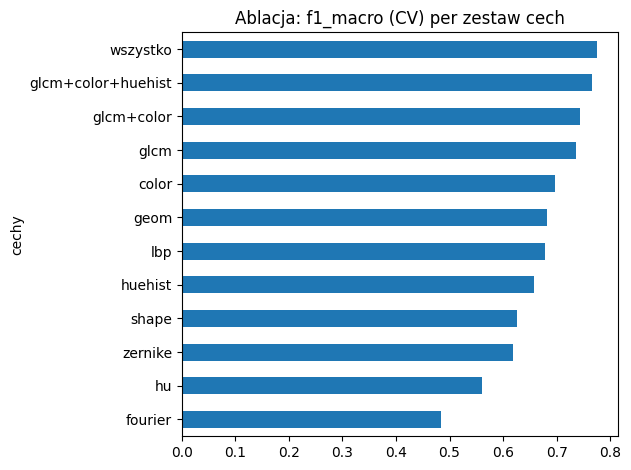

In [17]:
ablacja.set_index("cechy")["cv_f1"].iloc[::-1].plot.barh(
    title="Ablacja: f1_macro (CV) per zestaw cech")
plt.tight_layout(); plt.show()

### 7.4 Segmentacja: Otsu vs HSV

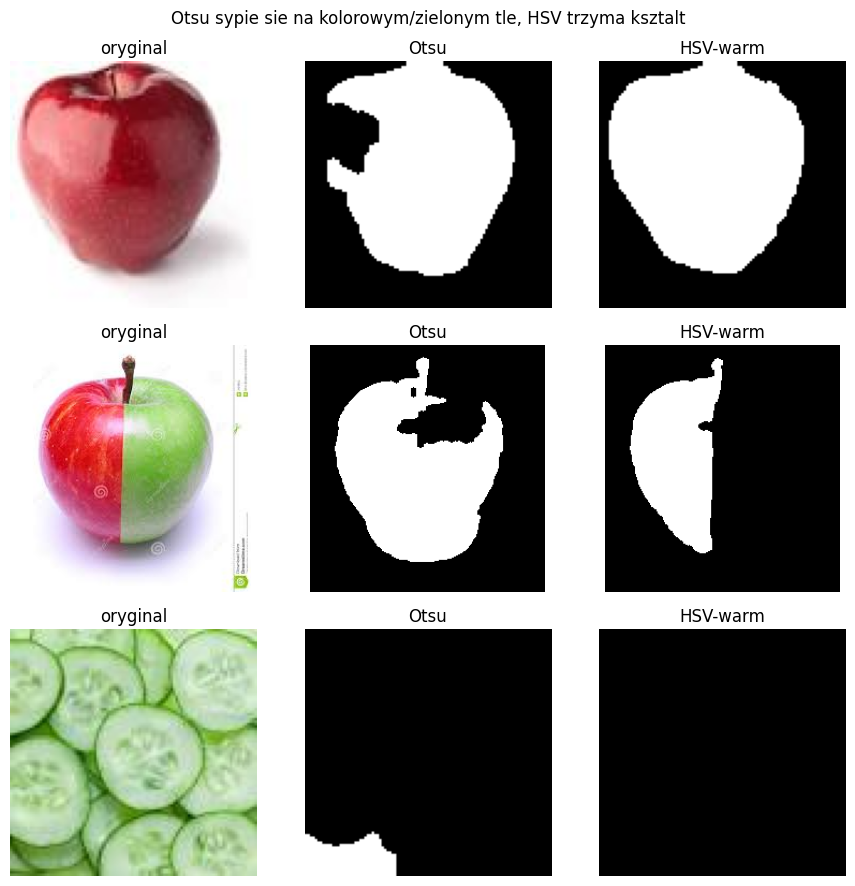

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for r, i in enumerate([0, 80, 200]):
    base = preprocessing.remove_artifacts(X_train_img[i])
    mo = preprocessing.segment_foreground(base, method="otsu")
    mh = preprocessing.segment_foreground(base, method="hsv", hsv_target="warm")
    axes[r, 0].imshow(X_train_img[i]); axes[r, 0].set_title("oryginal")
    axes[r, 1].imshow(mo, cmap="gray"); axes[r, 1].set_title("Otsu")
    axes[r, 2].imshow(mh, cmap="gray"); axes[r, 2].set_title("HSV-warm")
    for a in axes[r]:
        a.axis("off")
plt.suptitle("Otsu sypie sie na kolorowym/zielonym tle, HSV trzyma ksztalt")
plt.tight_layout(); plt.show()

In [19]:
# liczbowe podsumowanie do wnioskow
acc = tabela.loc[best_name, "accuracy"]; f1 = tabela.loc[best_name, "f1_macro"]
base = max(np.bincount(splits["y_test"])) / len(splits["y_test"])
pojedyncze = ablacja[ablacja["cechy"].isin(list(USE))].reset_index(drop=True)
print("BEST", best_name, round(acc, 3), round(f1, 3))
print("BASE", round(base, 3))
print("CM", cm.tolist(), list(le.classes_))
print("IMP", list(waznosc_rodzin.index), [round(float(x), 3) for x in waznosc_rodzin.values])
print("ABL_SINGLE", pojedyncze.iloc[0]["cechy"], pojedyncze.iloc[0]["cv_f1"])
print("ABL_TOP", ablacja.iloc[0]["cechy"], ablacja.iloc[0]["cv_f1"])

BEST knn 0.814 0.81
BASE 0.557
CM [[47, 7], [11, 32]] ['apple', 'tomato']
IMP ['glcm', 'color', 'shape', 'zernike', 'huehist', 'fourier', 'lbp', 'geom', 'hu'] [0.493, 0.243, 0.065, 0.055, 0.042, 0.032, 0.029, 0.023, 0.017]
ABL_SINGLE glcm 0.736
ABL_TOP wszystko 0.776


## 8. Wnioski

- Najwięcej sygnału niesie **tekstura GLCM** — i wg ważności w RandomForest (wykres 7.2), i w ablacji, gdzie sama daje najlepsze CV f1 = 0.736 (sekcja 7.3).
- Najlepszy zestaw cech w ablacji to **wszystko** (CV f1 = 0.776) — łączenie tekstury i koloru
  bije pojedyncze rodziny.
- Kształt (geometria, Zernike, Fourier, Hu) wnosi najmniej — jabłko i pomidor są podobnie okrągłe,
  więc kontur słabo różnicuje (widać to na wykresie ważności i w ablacji).
- Najlepszy klasyfikator: **knn** — na zbiorze testowym **accuracy = 0.814**, **f1_macro = 0.81**
  (baseline klasy większościowej = 0.557).
- Pomyłki: 7 apple wzięto za tomato i 11 tomato za apple — błędy idą w obie strony (PCA w 7.1 pokazuje,
  że klasy mocno się nakładają).
- Segmentacja: Otsu rozpada się na kolorowym/zielonym tle, HSV trzyma kształt owocu (sekcja 7.4),
  dlatego cechy koloru i kształtu liczymy na masce HSV.
- Zbiór jest trudny: obie klasy czerwone i okrągłe, część zdjęć to kiście, owoce pokrojone albo różne
  tła — to ogranicza górną granicę dla cech klasycznych.